# Reduksi Dimensi Data Iris Menggunakan Principal Component Analysis (PCA)

**Nama**    : Farhan Ramadhan Praditya  
**NIM** : 101052300116  

---

## Pendahuluan

Dataset yang memiliki banyak fitur seringkali sulit untuk dianalisis dan divisualisasikan secara langsung. Principal Component Analysis (PCA) merupakan salah satu metode reduksi dimensi yang banyak digunakan dalam machine learning untuk mengatasi permasalahan tersebut. PCA bekerja dengan cara mencari komponen baru (principal components) yang merupakan kombinasi linear dari fitur asli, di mana komponen pertama menjelaskan variansi terbesar pada data, diikuti komponen kedua, dan seterusnya.

Pada notebook ini, PCA akan diterapkan pada dataset Iris untuk mereduksi dimensi dari 4 fitur menjadi 2 komponen utama. Tujuannya adalah mempermudah visualisasi dan analisis data tanpa kehilangan banyak informasi penting.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optimasi ukuran gambar di notebook
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 80
sns.set_style('whitegrid')

## 2. Load Dataset

Dataset Iris diambil langsung dari modul `sklearn.datasets`. Dataset ini berisi 150 sampel bunga iris dari 3 spesies, dengan 4 fitur pengukuran (panjang & lebar sepal serta petal).

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print('Jumlah data  :', df.shape[0])
print('Jumlah fitur :', df.shape[1] - 1)
print('Spesies      :', list(df['species'].unique()))
print('\nDistribusi tiap spesies:')
print(df['species'].value_counts())

Jumlah data  : 150
Jumlah fitur : 4
Spesies      : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Distribusi tiap spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Dataset terdiri dari 150 data dengan 4 fitur numerik. Distribusi tiap spesies seimbang dengan 50 data per kelas, sehingga tidak ada permasalahan class imbalance yang perlu ditangani.

## 3. Exploratory Data Analysis

In [4]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


Tidak ditemukan missing value pada dataset.

In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Dari statistik deskriptif terlihat bahwa rentang nilai antar fitur cukup bervariasi. Misalnya, *sepal length* memiliki rentang 4.3–7.9, sementara *petal width* hanya 0.1–2.5. Perbedaan skala ini menjadi alasan kuat untuk melakukan standardisasi sebelum menerapkan PCA.

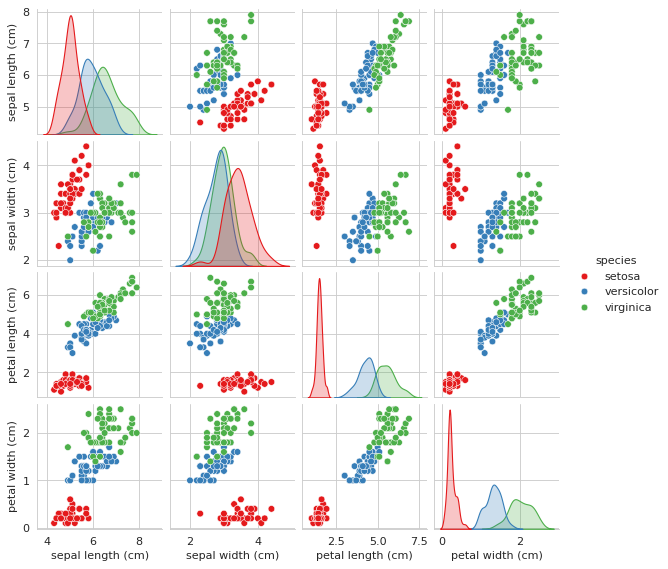

In [6]:
# Visualisasi hubungan antar fitur menggunakan pair plot
g = sns.pairplot(df, hue='species', palette='Set1', height=1.8, aspect=1)
plt.show()

Hasil pair plot menunjukkan bahwa:

- Spesies **setosa** dapat dipisahkan dengan jelas dari spesies lain, terutama berdasarkan fitur *petal length* dan *petal width*.
- Spesies **versicolor** dan **virginica** memiliki sebagian area yang overlap pada hampir semua kombinasi fitur.

## 4. Preprocessing Data

Sebelum menerapkan PCA, data perlu distandardisasi menggunakan `StandardScaler` agar setiap fitur memiliki mean = 0 dan standar deviasi = 1.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean tiap fitur setelah standardisasi :', np.round(X_scaled.mean(axis=0), 4))
print('Std tiap fitur setelah standardisasi  :', np.round(X_scaled.std(axis=0), 4))

Mean tiap fitur setelah standardisasi : [-0. -0. -0. -0.]
Std tiap fitur setelah standardisasi  : [1. 1. 1. 1.]


Hasil standardisasi menunjukkan mean mendekati 0 dan standar deviasi sama dengan 1 untuk semua fitur.

## 5. Penerapan PCA

### 5.1 Analisis Jumlah Komponen Optimal

Sebelum menentukan jumlah komponen akhir, dilakukan analisis terhadap seluruh 4 komponen terlebih dahulu untuk melihat berapa banyak variansi yang dijelaskan oleh masing-masing komponen.

In [8]:
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

print('Explained variance ratio tiap komponen:')
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1}: {var*100:.2f}%')

cumulative = np.cumsum(pca_full.explained_variance_ratio_)
print(f'\nVariansi kumulatif PC1+PC2     : {cumulative[1]*100:.2f}%')
print(f'Variansi kumulatif PC1+PC2+PC3 : {cumulative[2]*100:.2f}%')

Explained variance ratio tiap komponen:
  PC1: 72.96%
  PC2: 22.85%
  PC3: 3.67%
  PC4: 0.52%

Variansi kumulatif PC1+PC2     : 95.81%
Variansi kumulatif PC1+PC2+PC3 : 99.48%


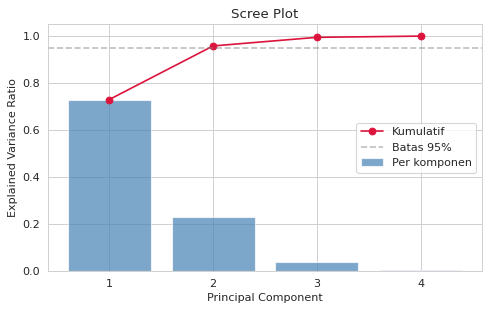

In [9]:
# Scree plot
plt.figure(figsize=(7, 4))
components = range(1, 5)
plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue', label='Per komponen')
plt.plot(components, cumulative, marker='o', color='crimson', label='Kumulatif')
plt.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='Batas 95%')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(components)
plt.legend()
plt.show()

Berdasarkan scree plot, dua komponen pertama sudah mampu menjelaskan lebih dari 95% variansi data. Oleh karena itu, dipilih `n_components = 2` untuk reduksi dimensi.

### 5.2 Reduksi ke 2 Dimensi

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Dimensi sebelum PCA :', X_scaled.shape)
print('Dimensi setelah PCA :', X_pca.shape)

Dimensi sebelum PCA : (150, 4)
Dimensi setelah PCA : (150, 2)


In [11]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = df['species']
df_pca.head()

,PC1,PC2,species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


## 6. Visualisasi Hasil PCA

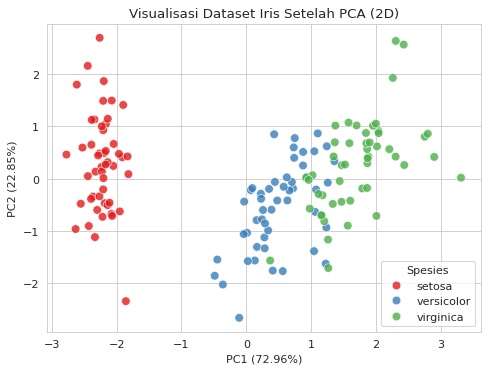

In [12]:
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species',
                palette='Set1', s=60, alpha=0.8)
plt.xlabel(f'PC1 ({pc1_var:.2f}%)')
plt.ylabel(f'PC2 ({pc2_var:.2f}%)')
plt.title('Visualisasi Dataset Iris Setelah PCA (2D)')
plt.legend(title='Spesies')
plt.show()

Visualisasi 2D menunjukkan bahwa walaupun dimensi data telah dikurangi dari 4 menjadi 2, ketiga spesies masih dapat dibedakan dengan cukup baik:

- **Setosa** terpisah secara jelas pada sisi kiri grafik.
- **Versicolor** dan **virginica** berdekatan di tengah hingga kanan grafik, dengan sedikit overlap.

Pola pemisahan ini konsisten dengan hasil pair plot sebelumnya.

## 7. Analisis Loadings (Kontribusi Fitur)

Loadings menunjukkan seberapa besar pengaruh setiap fitur asli terhadap principal component yang terbentuk.

In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=iris.feature_names
)
loadings

,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942


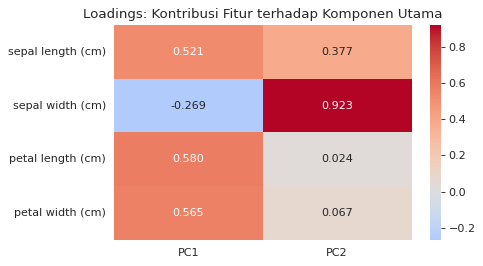

In [14]:
plt.figure(figsize=(6, 3.5))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Loadings: Kontribusi Fitur terhadap Komponen Utama')
plt.show()

Berdasarkan tabel dan heatmap loadings:

- **PC1** dipengaruhi secara dominan oleh *petal length*, *petal width*, dan *sepal length*, ketiganya bernilai positif. PC1 merepresentasikan ukuran keseluruhan bunga.
- **PC2** dipengaruhi paling besar oleh *sepal width* dengan nilai negatif. Komponen ini lebih spesifik menggambarkan variasi lebar sepal.

Dengan demikian, fitur petal (panjang dan lebar) menjadi fitur paling informatif dalam membedakan ketiga spesies iris.

## 8. Perbandingan: Dengan dan Tanpa Standardisasi

Sebagai eksperimen tambahan, dilakukan perbandingan hasil PCA dengan dan tanpa standardisasi untuk memverifikasi pentingnya tahap standardisasi.

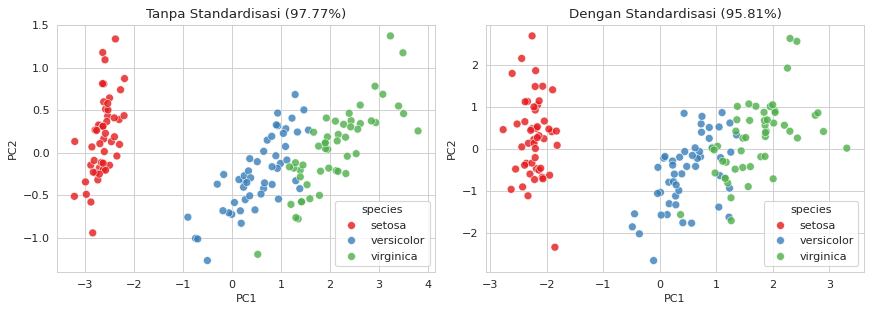

In [15]:
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

df_raw = pd.DataFrame(X_pca_raw, columns=['PC1', 'PC2'])
df_raw['species'] = df['species']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(data=df_raw, x='PC1', y='PC2', hue='species',
                palette='Set1', s=50, alpha=0.8, ax=axes[0])
axes[0].set_title(f'Tanpa Standardisasi ({sum(pca_raw.explained_variance_ratio_)*100:.2f}%)')

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species',
                palette='Set1', s=50, alpha=0.8, ax=axes[1])
axes[1].set_title(f'Dengan Standardisasi ({sum(pca.explained_variance_ratio_)*100:.2f}%)')

plt.tight_layout()
plt.show()

Meskipun variansi yang dijelaskan pada PCA tanpa standardisasi terlihat lebih tinggi, hasil tersebut bias karena hanya didominasi oleh fitur dengan skala besar (*petal length* dan *sepal length*). PCA dengan standardisasi memberikan kontribusi yang seimbang dari setiap fitur.

## 9. Kesimpulan

Berdasarkan hasil eksperimen, dapat disimpulkan beberapa hal berikut:

1. **PCA berhasil mereduksi dimensi dataset Iris dari 4 fitur menjadi 2 komponen utama**, dengan total variansi yang dipertahankan sekitar 95.81%. Hanya sekitar 4% informasi yang hilang akibat reduksi dimensi.
2. **Visualisasi hasil PCA tetap mampu menampilkan pola pemisahan antar spesies**. Setosa terpisah dengan jelas, sementara versicolor dan virginica masih dapat dibedakan meskipun memiliki sedikit overlap.
3. **Fitur *petal length* dan *petal width* memberikan kontribusi terbesar terhadap PC1**, sehingga dapat disimpulkan sebagai fitur paling informatif untuk membedakan ketiga spesies iris.
4. **Standardisasi merupakan tahap penting** sebelum menerapkan PCA, terbukti dari perbandingan hasil dengan dan tanpa standardisasi.

Secara keseluruhan, PCA terbukti efektif sebagai metode reduksi dimensi yang mempermudah visualisasi dan analisis data berdimensi tinggi tanpa kehilangan banyak informasi penting.